In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('train.csv',usecols=['Age','Fare','Survived'])

In [3]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [4]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [5]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [6]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [7]:
X_train

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458
...,...,...
534,30.0,8.6625
584,NaN,8.7125
493,71.0,49.5042
527,NaN,221.7792


In [8]:
X_train['Age_imputed'] = X_train['Age']
X_test['Age_imputed'] = X_test['Age']

In [9]:
X_test.tail()

,Age,Fare,Age_imputed
89,24.0,8.0500,24.0
80,22.0,9.0000,22.0
846,NaN,69.5500,NaN
870,26.0,7.8958,26.0
251,29.0,10.4625,29.0


In [12]:
# For training set
X_train.loc[X_train['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(X_train['Age_imputed'].isnull().sum(), replace=True)
    .values
)

# For test set
X_test.loc[X_test['Age_imputed'].isnull(), 'Age_imputed'] = (
    X_train['Age'].dropna()
    .sample(X_test['Age_imputed'].isnull().sum(), replace=True)
    .values
)


In [13]:
X_train['Age'].dropna().sample(X_train['Age'].isnull().sum()).values

array([24.  , 37.  , 28.  , 35.  , 30.  , 29.  , 50.  , 46.  , 28.  ,
       21.  , 33.  , 25.  , 27.  , 50.  , 43.  , 21.  , 31.  , 29.  ,
       39.  , 35.  , 46.  , 16.  , 31.  , 26.  , 27.  , 34.5 ,  9.  ,
       18.  , 25.  , 23.  , 30.  , 48.  , 23.  , 21.  , 25.  , 47.  ,
       40.5 ,  0.83, 20.  , 24.  , 30.  , 34.  , 17.  , 11.  ,  2.  ,
       30.  , 21.  , 64.  , 58.  , 21.  , 28.  , 18.  , 16.  , 35.  ,
       31.  , 18.  , 34.  , 50.  , 17.  , 16.  , 23.  , 32.  ,  2.  ,
       40.  , 20.  , 27.  , 22.  , 35.  , 31.  , 50.  , 27.  , 11.  ,
       27.  , 24.  , 21.  , 16.  , 39.  , 56.  , 30.  ,  4.  , 63.  ,
       61.  , 14.  , 28.  , 16.  ,  8.  , 12.  , 22.  , 48.  , 45.  ,
       47.  , 42.  , 41.  , 19.  , 45.  , 33.  , 52.  ,  4.  , 71.  ,
       28.  , 20.  , 29.  ,  2.  , 22.  , 35.  ,  8.  , 62.  , 39.  ,
       25.  , 58.  , 51.  , 35.  , 54.  , 22.  , 24.  , 45.  , 22.  ,
       31.  , 18.  , 37.  , 19.  , 32.  , 27.  , 57.  , 29.  , 43.  ,
       32.  , 29.  ,

In [14]:
X_train['Age'].isnull().sum()

np.int64(148)

In [15]:
X_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,26.0
493,71.0,49.5042,71.0
527,NaN,221.7792,12.0


C:\Users\shiva\AppData\Local\Temp\ipykernel_14792\629994495.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'],label='Original',hist=False)
C:\Users\shiva\AppData\Local\Temp\ipykernel_14792\629994495.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['A

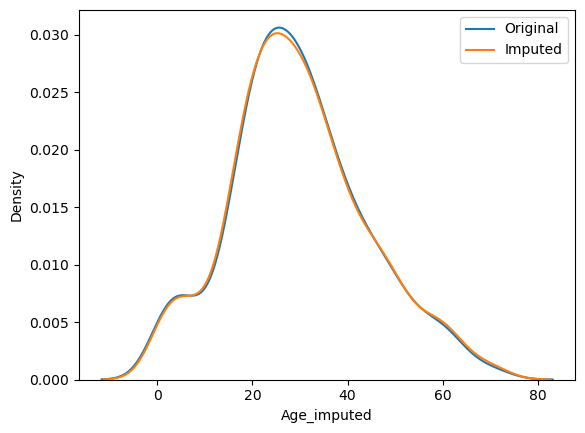

In [16]:
sns.distplot(X_train['Age'],label='Original',hist=False)
sns.distplot(X_train['Age_imputed'],label='Imputed',hist=False)
plt.legend()
plt.show()

In [19]:
print('Original variable variance:',X_train['Age'].var())
print('variance after random imputation :',X_train['Age_imputed'].var())

Original variable variance: 204.3495133904614
variance after random imputation : 208.82546963585835


In [20]:
X_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,61.283753
Age,71.512440,204.349513,204.349513
Age_imputed,61.283753,204.349513,208.825470


<Axes: >

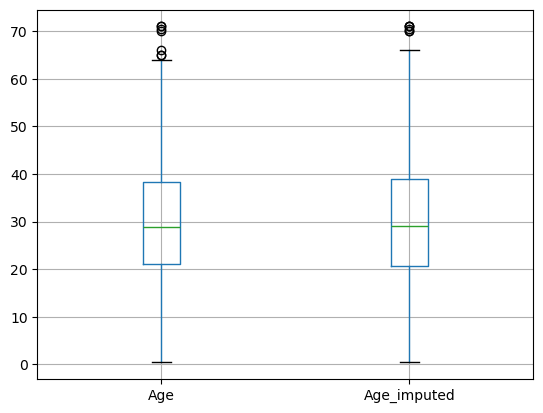

In [21]:
X_train[['Age','Age_imputed']].boxplot()

In [24]:
# Grab an example row (e.g., the first row) to act as your "observation"
observation = X_train.iloc[0] 

# Now the sample function will work because 'observation' exists!
sampled_value = X_train['Age'].dropna().sample(1, random_state=int(observation['Fare']))
print(sampled_value)

399    28.0
Name: Age, dtype: float64


In [31]:
data = pd.read_csv('house-train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [32]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [33]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [39]:
X=data
y = data['SalePrice']

In [40]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [41]:
X_train.columns

Index(['FireplaceQu', 'GarageQual', 'SalePrice'], dtype='object')

In [42]:

X_train['GarageQual_imputed'] = X_train['GarageQual']
X_test['GarageQual_imputed'] = X_test['GarageQual']

X_train['FireplaceQu_imputed'] = X_train['FireplaceQu']
X_test['FireplaceQu_imputed'] = X_test['FireplaceQu']

In [43]:
X_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
1218,NaN,NaN,80500,NaN,NaN
1206,NaN,TA,107000,TA,NaN
659,NaN,TA,167000,TA,NaN
242,NaN,Fa,79000,Fa,NaN
703,Po,TA,140000,TA,Po


In [44]:
X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual'].isnull().sum()).values
X_test['GarageQual_imputed'][X_test['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_test['GarageQual'].isnull().sum()).values

X_train['FireplaceQu_imputed'][X_train['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_train['FireplaceQu'].isnull().sum()).values
X_test['FireplaceQu_imputed'][X_test['FireplaceQu_imputed'].isnull()] = X_train['FireplaceQu'].dropna().sample(X_test['FireplaceQu'].isnull().sum()).values

C:\Users\shiva\AppData\Local\Temp\ipykernel_14792\856878696.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  X_train['GarageQual_imputed'][X_train['GarageQual_imputed'].isnull()] = X_train['GarageQual'].dropna().sample(X_train['GarageQual

In [45]:
temp = pd.concat([X_train['GarageQual'].value_counts()/len(X_train['GarageQual'].dropna()),X_train['GarageQual_imputed'].value_counts()/len(X_train)],axis=1)
temp.columns = ['original','imputed']

In [46]:
temp

,original,imputed
TA,0.951043,0.952055
Fa,0.037171,0.036815
Gd,0.009973,0.009418
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [47]:
temp = pd.concat([X_train['FireplaceQu'].value_counts()/len(X_train['FireplaceQu'].dropna()),X_train['FireplaceQu_imputed'].value_counts()/len(df)],axis=1)
temp.columns = ['original','imputed']
temp

,original,imputed
Gd,0.494272,0.648709
TA,0.412439,0.537598
Fa,0.040917,0.056117
Po,0.027823,0.038159
Ex,0.024550,0.030303


C:\Users\shiva\AppData\Local\Temp\ipykernel_14792\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
C:\Users\shiva\AppData\Local\Temp\ipykernel_14792\1827688635.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457a

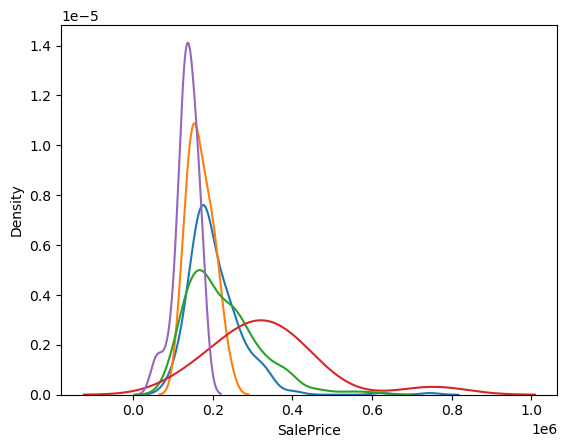

In [52]:
for category in X_train['FireplaceQu'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu'] == category]['SalePrice'],hist=False,label=category)
plt.show()

C:\Users\shiva\AppData\Local\Temp\ipykernel_14792\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
C:\Users\shiva\AppData\Local\Temp\ipykernel_14792\722808554.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `kdeplot` (an axes-level function for kernel density plots).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed29

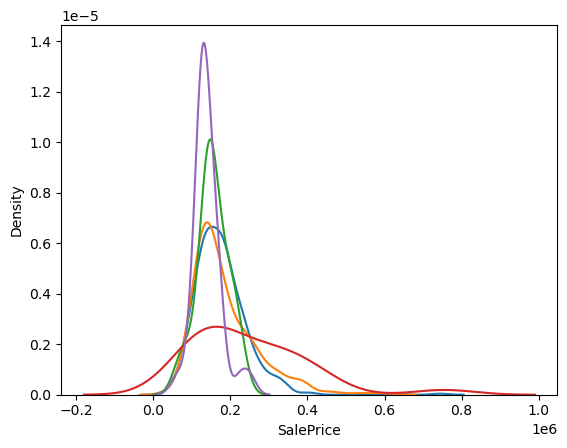

In [54]:
for category in X_train['FireplaceQu_imputed'].dropna().unique():
    sns.distplot(X_train[X_train['FireplaceQu_imputed'] == category]['SalePrice'],hist=False,label=category)
plt.show()